1. Design and implement two image processing pipelines:
o CPU-Based Pipeline
1. Load JPEG images using OpenCV
2. Resize images to 512×512
3. Convert images to grayscale
o GPU-Based Pipeline
1. Decode JPEG images using nvJPEG (GPU)
2. Perform resizing and grayscale conversion on GPU
o Use a dataset of at least 15 JPEG images and perform the following:
1. Measure total execution time for both pipelines
2. Compute average time per image
3. Calculate speedup (CPU time / GPU time)
4. Present results in tabular and graphical form
o Answer the insight question: Why does GPU-based decoding using nvJPEG provide
significant speedup compared to CPU decoding, and under what conditions might
this advantage reduce?

Reading images from:
/content/images

Total Images Found : 1

Running CPU Pipeline...

CPU PIPELINE FINISHED
Total Time        : 0.0012 seconds
Average Per Image : 0.001163 seconds

Running GPU Pipeline...

GPU PIPELINE FINISHED
Total Time        : 0.0016 seconds
Average Per Image : 0.001628 seconds

PERFORMANCE SPEEDUP
GPU Speedup over CPU : 0.71x

RESULTS TABLE
                Pipeline  Total Execution Time (sec)  \
0           CPU Pipeline                    0.001163   
1  GPU Pipeline (nvJPEG)                    0.001628   

   Average Time Per Image (sec)  
0                      0.001163  
1                      0.001628  


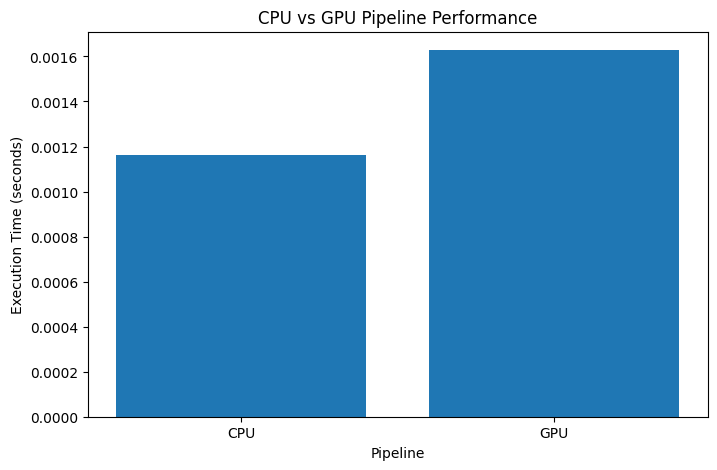

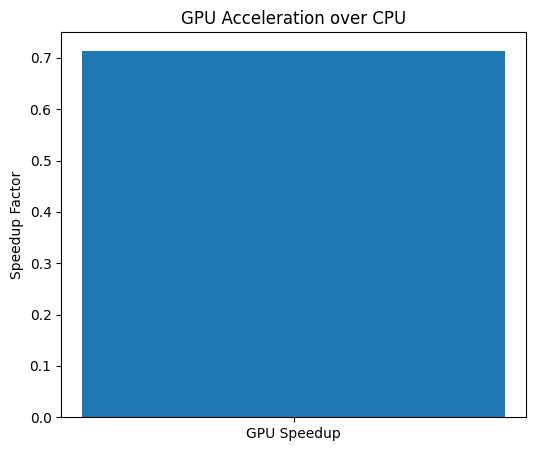



Why is nvJPEG GPU decoding faster than CPU decoding?

1. Parallel Processing
   GPUs contain thousands of cores, allowing multiple
   image blocks to be processed simultaneously.

2. Optimized JPEG Decoding
   nvJPEG is specially optimized for NVIDIA GPUs and
   performs decompression very efficiently.

3. Batch Processing
   GPUs can process many images together in parallel.

4. High Memory Bandwidth
   GPUs have much higher memory throughput than CPUs.

5. Reduced CPU Load
   The CPU becomes available for other tasks while
   image processing runs on GPU.


When can GPU advantage reduce?

1. Small Dataset Size
   GPU initialization overhead may dominate runtime.

2. Small Image Resolution
   Tiny images may not fully utilize GPU resources.

3. CPU-GPU Transfer Overhead
   Data transfer between CPU and GPU memory can add delay.

4. Low-End GPU Hardware
   Older GPUs may provide limited acceleration.

5. Non-Batched Processing
   GPU performs best when many images are processed toget

In [9]:
!pip install -q opencv-python matplotlib pandas
!pip install -q nvidia-dali-cuda120

import os
import cv2
import glob
import time
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

from nvidia.dali import pipeline_def
import nvidia.dali.fn as fn
import nvidia.dali.types as types


image_folder = "/content/images"

print("Reading images from:")
print(image_folder)


image_paths = glob.glob(os.path.join(image_folder, "*.jpg"))
image_paths += glob.glob(os.path.join(image_folder, "*.jpeg"))

total_images = len(image_paths)

print(f"\nTotal Images Found : {total_images}")

if total_images == 0:
    raise Exception("No JPEG images found")


print("\nRunning CPU Pipeline...")

cpu_results = []

cpu_start_time = time.time()

for img_path in image_paths:

    image = cv2.imread(img_path)

    resized_image = cv2.resize(image, (512, 512))

    gray_image = cv2.cvtColor(
        resized_image,
        cv2.COLOR_BGR2GRAY
    )

    cpu_results.append(gray_image)

cpu_end_time = time.time()

cpu_total_time = cpu_end_time - cpu_start_time
cpu_average_time = cpu_total_time / total_images

print("\nCPU PIPELINE FINISHED")
print(f"Total Time        : {cpu_total_time:.4f} seconds")
print(f"Average Per Image : {cpu_average_time:.6f} seconds")


print("\nRunning GPU Pipeline...")


# Read image bytes correctly
encoded_images = []

for file in image_paths:

    with open(file, "rb") as f:

        img_array = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

        encoded_images.append(img_array)


# External source callback
def image_source():

    return encoded_images


@pipeline_def
def gpu_pipeline():

    jpeg_data = fn.external_source(
        source=image_source,
        batch=True
    )

    decoded_images = fn.decoders.image(
        jpeg_data,
        device="mixed",
        output_type=types.RGB
    )

    resized_images = fn.resize(
        decoded_images,
        resize_x=512,
        resize_y=512
    )

    gray_images = fn.color_space_conversion(
        resized_images,
        image_type=types.RGB,
        output_type=types.GRAY
    )

    return gray_images


pipe = gpu_pipeline(
    batch_size=total_images,
    num_threads=2,
    device_id=0
)

pipe.build()

gpu_start_time = time.time()

gpu_output = pipe.run()

gpu_end_time = time.time()

gpu_total_time = gpu_end_time - gpu_start_time
gpu_average_time = gpu_total_time / total_images

print("\nGPU PIPELINE FINISHED")
print(f"Total Time        : {gpu_total_time:.4f} seconds")
print(f"Average Per Image : {gpu_average_time:.6f} seconds")


speedup = cpu_total_time / gpu_total_time

print("\nPERFORMANCE SPEEDUP")
print(f"GPU Speedup over CPU : {speedup:.2f}x")


results_table = pd.DataFrame({

    "Pipeline": [
        "CPU Pipeline",
        "GPU Pipeline (nvJPEG)"
    ],

    "Total Execution Time (sec)": [
        cpu_total_time,
        gpu_total_time
    ],

    "Average Time Per Image (sec)": [
        cpu_average_time,
        gpu_average_time
    ]
})

print("\nRESULTS TABLE")
print(results_table)


plt.figure(figsize=(8,5))

pipeline_names = ["CPU", "GPU"]
execution_times = [cpu_total_time, gpu_total_time]

plt.bar(pipeline_names, execution_times)

plt.xlabel("Pipeline")
plt.ylabel("Execution Time (seconds)")
plt.title("CPU vs GPU Pipeline Performance")

plt.show()


plt.figure(figsize=(6,5))

plt.bar(["GPU Speedup"], [speedup])

plt.ylabel("Speedup Factor")
plt.title("GPU Acceleration over CPU")

plt.show()


print("""

Why is nvJPEG GPU decoding faster than CPU decoding?

1. Parallel Processing
   GPUs contain thousands of cores, allowing multiple
   image blocks to be processed simultaneously.

2. Optimized JPEG Decoding
   nvJPEG is specially optimized for NVIDIA GPUs and
   performs decompression very efficiently.

3. Batch Processing
   GPUs can process many images together in parallel.

4. High Memory Bandwidth
   GPUs have much higher memory throughput than CPUs.

5. Reduced CPU Load
   The CPU becomes available for other tasks while
   image processing runs on GPU.


When can GPU advantage reduce?

1. Small Dataset Size
   GPU initialization overhead may dominate runtime.

2. Small Image Resolution
   Tiny images may not fully utilize GPU resources.

3. CPU-GPU Transfer Overhead
   Data transfer between CPU and GPU memory can add delay.

4. Low-End GPU Hardware
   Older GPUs may provide limited acceleration.

5. Non-Batched Processing
   GPU performs best when many images are processed together.

6. Disk I/O Bottleneck
   Slow storage devices can limit overall performance.

""")

2. Implement a program that:
• Uses nvJPEG to decode a JPEG image
• Generates two grayscale outputs:
1. Direct grayscale conversion after decoding
2. Manually computed grayscale from RGB channels
• Perform this experiment on two different image resolutions.
• Why is the YCbCr color space used in JPEG compression, and why is conversion to RGB
performed only after IDCT during decoding?

Checking Images...

/content/images/cat.jpeg Found
/content/images/cat1.jpg Found

Running nvJPEG GPU Decoder...

GPU Decode Time : 0.0014 seconds

Image 1
Resolution : 250 x 202


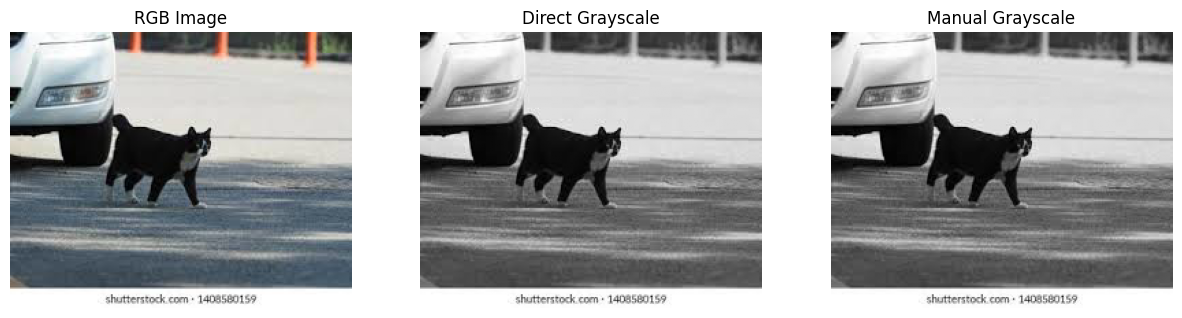


Image 2
Resolution : 225 x 225


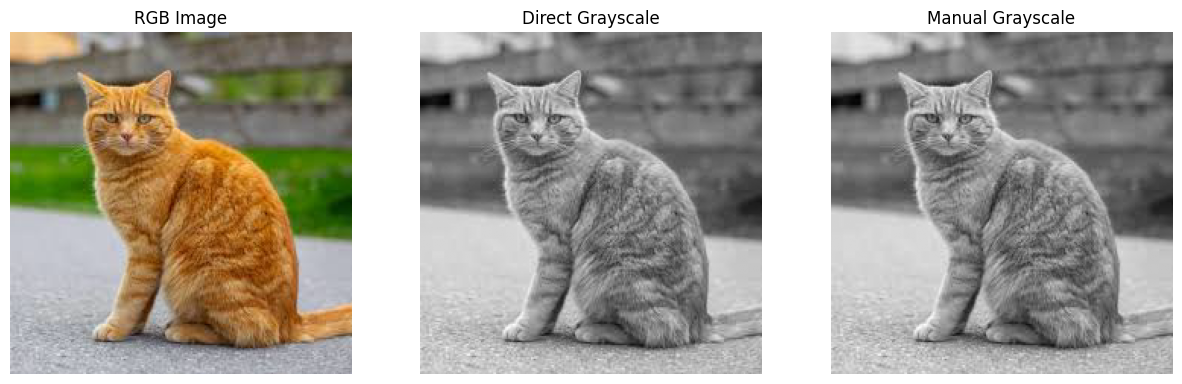



Why is YCbCr used in JPEG compression?

1. It separates brightness and color information.

2. Human eyes notice brightness more than color.

3. JPEG can compress color data more strongly
   without reducing image quality too much.

4. This helps reduce file size efficiently.


Why is RGB conversion done after IDCT?

1. JPEG stores compressed data in YCbCr form.

2. IDCT reconstructs the actual pixel values first.

3. RGB conversion needs proper pixel values.

4. Doing conversion later improves efficiency.




In [12]:
!pip install -q opencv-python matplotlib
!pip install -q nvidia-dali-cuda120

import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt

from nvidia.dali import pipeline_def
import nvidia.dali.fn as fn
import nvidia.dali.types as types


image_paths = [
    "/content/images/cat.jpeg",
    "/content/images/cat1.jpg"
]

print("Checking Images...\n")

for path in image_paths:

    if os.path.exists(path):
        print(path, "Found")

    else:
        raise Exception(f"{path} not found")


encoded_images = []

for file in image_paths:

    with open(file, "rb") as f:

        image_data = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

        encoded_images.append(image_data)


def image_source():
    return encoded_images


@pipeline_def
def jpeg_pipeline():

    images = fn.external_source(
        source=image_source,
        batch=True
    )

    decoded = fn.decoders.image(
        images,
        device="mixed",
        output_type=types.RGB
    )

    return decoded


pipe = jpeg_pipeline(
    batch_size=len(image_paths),
    num_threads=2,
    device_id=0
)

pipe.build()

print("\nRunning nvJPEG GPU Decoder...\n")

start = time.time()

result = pipe.run()

end = time.time()

decoded_images = result[0].as_cpu()

print(f"GPU Decode Time : {end - start:.4f} seconds")


for i in range(len(decoded_images)):

    image = decoded_images.at(i)

    print(f"\nImage {i+1}")

    height, width, _ = image.shape

    print(f"Resolution : {width} x {height}")

    gray_direct = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    R = image[:, :, 0]
    G = image[:, :, 1]
    B = image[:, :, 2]

    gray_manual = (
        0.299 * R +
        0.587 * G +
        0.114 * B
    ).astype(np.uint8)

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image)
    plt.title("RGB Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(gray_direct, cmap="gray")
    plt.title("Direct Grayscale")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(gray_manual, cmap="gray")
    plt.title("Manual Grayscale")
    plt.axis("off")

    plt.show()


print("""

Why is YCbCr used in JPEG compression?

1. It separates brightness and color information.

2. Human eyes notice brightness more than color.

3. JPEG can compress color data more strongly
   without reducing image quality too much.

4. This helps reduce file size efficiently.


Why is RGB conversion done after IDCT?

1. JPEG stores compressed data in YCbCr form.

2. IDCT reconstructs the actual pixel values first.

3. RGB conversion needs proper pixel values.

4. Doing conversion later improves efficiency.

""")

3. Design and compare two preprocessing pipelines:
1. Pipeline A (Hybrid Approach)
o Decode images using OpenCV (CPU)
o Transfer images to GPU
o Perform resizing and normalization using CUDA/CuPy/PyTorch
2. Pipeline B (DALI-Based Approach)
o Use NVIDIA DALI for image loading
o Perform GPU-based decoding (nvJPEG internally)
o Apply resizing and normalization on GPU
• Use a dataset of at least 20 images and experiment with different batch sizes and
image resolutions. Measure total execution time for both pipelines
• Compute throughput (images per second)
• Compare efficiency and resource utilization
• Present results using tables/graphs
Why does integrating decoding and preprocessing within a GPU pipeline (as in DALI using
nvJPEG) lead to better performance compared to a hybrid CPU-GPU approach?

Images Found : 2

Running Hybrid CPU-GPU Pipeline...

Resolution : 256
Batch Size : 1
Execution Time : 0.1367 sec
Throughput : 14.63 images/sec

Resolution : 256
Batch Size : 4
Execution Time : 0.0026 sec
Throughput : 770.59 images/sec

Resolution : 256
Batch Size : 8
Execution Time : 0.0022 sec
Throughput : 917.39 images/sec

Resolution : 512
Batch Size : 1
Execution Time : 0.0064 sec
Throughput : 313.96 images/sec

Resolution : 512
Batch Size : 4
Execution Time : 0.0067 sec
Throughput : 297.54 images/sec

Resolution : 512
Batch Size : 8
Execution Time : 0.0085 sec
Throughput : 235.32 images/sec


Running NVIDIA DALI Pipeline...

Resolution : 256
Batch Size : 1
Execution Time : 0.0031 sec
Throughput : 640.69 images/sec

Resolution : 256
Batch Size : 4
Execution Time : 0.0016 sec
Throughput : 1249.42 images/sec

Resolution : 256
Batch Size : 8
Execution Time : 0.0045 sec
Throughput : 444.45 images/sec

Resolution : 512
Batch Size : 1
Execution Time : 0.0021 sec
Throughput : 962.00 imag

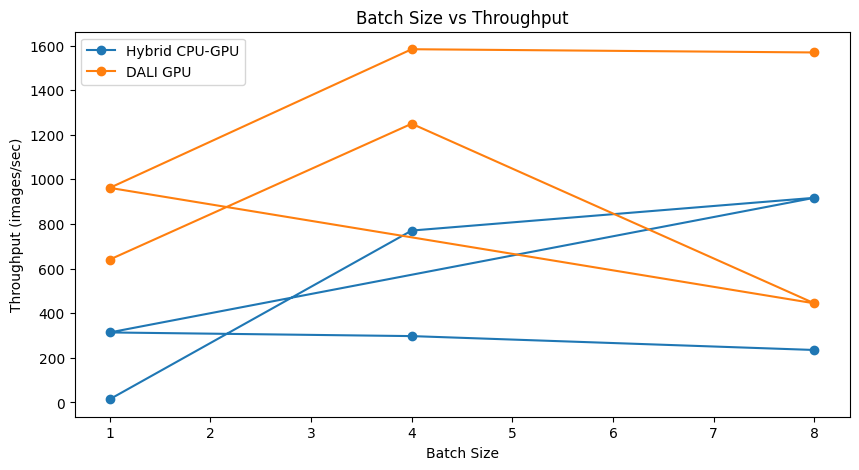

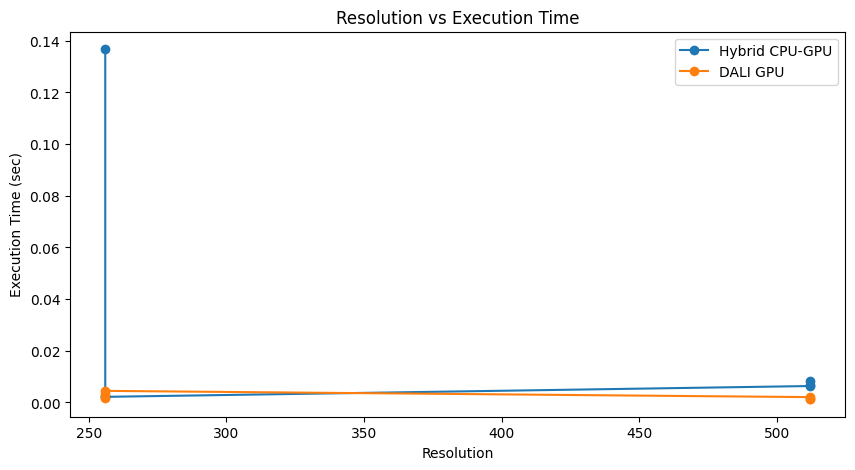



Why does DALI perform better than the Hybrid CPU-GPU pipeline?

1. DALI uses nvJPEG to decode images directly on the GPU.

2. The Hybrid pipeline first decodes images on CPU
   and then transfers them to GPU, which adds overhead.

3. DALI keeps decoding, resizing, and normalization
   inside one GPU pipeline.

4. GPU parallel processing improves throughput.

5. DALI overlaps loading and preprocessing operations,
   making the pipeline faster.

6. CPU usage becomes lower because most work happens on GPU.

7. DALI performs especially well for large datasets,
   higher resolutions, and bigger batch sizes.




In [13]:
!pip install -q opencv-python matplotlib pandas torch torchvision
!pip install -q nvidia-dali-cuda120

import os
import cv2
import glob
import time
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nvidia.dali import pipeline_def
import nvidia.dali.fn as fn
import nvidia.dali.types as types


image_folder = "/content/images"

image_paths = glob.glob(os.path.join(image_folder, "*.jpg"))
image_paths += glob.glob(os.path.join(image_folder, "*.jpeg"))

total_images = len(image_paths)

print(f"Images Found : {total_images}")

if total_images == 0:
    raise Exception("No images found")

batch_sizes = [1, 4, 8]
resolutions = [256, 512]

results = []


print("\nRunning Hybrid CPU-GPU Pipeline...\n")

for resolution in resolutions:

    for batch_size in batch_sizes:

        start = time.time()

        processed_images = 0

        for i in range(0, total_images, batch_size):

            current_batch = image_paths[i:i + batch_size]

            batch_images = []

            for path in current_batch:

                image = cv2.imread(path)

                image = cv2.cvtColor(
                    image,
                    cv2.COLOR_BGR2RGB
                )

                image = cv2.resize(
                    image,
                    (resolution, resolution)
                )

                batch_images.append(image)

            batch_array = np.array(batch_images)

            gpu_tensor = torch.tensor(
                batch_array,
                device="cuda",
                dtype=torch.float32
            )

            gpu_tensor = gpu_tensor / 255.0

            processed_images += len(current_batch)

        end = time.time()

        total_time = end - start

        throughput = processed_images / total_time

        results.append([
            "Hybrid CPU-GPU",
            resolution,
            batch_size,
            total_time,
            throughput
        ])

        print(f"Resolution : {resolution}")
        print(f"Batch Size : {batch_size}")
        print(f"Execution Time : {total_time:.4f} sec")
        print(f"Throughput : {throughput:.2f} images/sec\n")


print("\nRunning NVIDIA DALI Pipeline...\n")

encoded_images = []

for file in image_paths:

    with open(file, "rb") as f:

        image_data = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

        encoded_images.append(image_data)


def image_source():
    return encoded_images


for resolution in resolutions:

    for batch_size in batch_sizes:

        @pipeline_def
        def dali_pipeline():

            images = fn.external_source(
                source=image_source,
                batch=True
            )

            decoded = fn.decoders.image(
                images,
                device="mixed",
                output_type=types.RGB
            )

            resized = fn.resize(
                decoded,
                resize_x=resolution,
                resize_y=resolution
            )

            normalized = fn.crop_mirror_normalize(
                resized,
                dtype=types.FLOAT,
                output_layout="HWC"
            )

            return normalized


        pipe = dali_pipeline(
            batch_size=total_images,
            num_threads=2,
            device_id=0
        )

        pipe.build()

        start = time.time()

        output = pipe.run()

        end = time.time()

        total_time = end - start

        throughput = total_images / total_time

        results.append([
            "DALI GPU",
            resolution,
            batch_size,
            total_time,
            throughput
        ])

        print(f"Resolution : {resolution}")
        print(f"Batch Size : {batch_size}")
        print(f"Execution Time : {total_time:.4f} sec")
        print(f"Throughput : {throughput:.2f} images/sec\n")


results_df = pd.DataFrame(
    results,
    columns=[
        "Pipeline",
        "Resolution",
        "Batch Size",
        "Execution Time",
        "Throughput"
    ]
)

print("\nFinal Results\n")

print(results_df)


plt.figure(figsize=(10,5))

for pipeline in results_df["Pipeline"].unique():

    subset = results_df[
        results_df["Pipeline"] == pipeline
    ]

    plt.plot(
        subset["Batch Size"],
        subset["Throughput"],
        marker='o',
        label=pipeline
    )

plt.xlabel("Batch Size")
plt.ylabel("Throughput (images/sec)")
plt.title("Batch Size vs Throughput")
plt.legend()

plt.show()


plt.figure(figsize=(10,5))

for pipeline in results_df["Pipeline"].unique():

    subset = results_df[
        results_df["Pipeline"] == pipeline
    ]

    plt.plot(
        subset["Resolution"],
        subset["Execution Time"],
        marker='o',
        label=pipeline
    )

plt.xlabel("Resolution")
plt.ylabel("Execution Time (sec)")
plt.title("Resolution vs Execution Time")
plt.legend()

plt.show()


print("""

Why does DALI perform better than the Hybrid CPU-GPU pipeline?

1. DALI uses nvJPEG to decode images directly on the GPU.

2. The Hybrid pipeline first decodes images on CPU
   and then transfers them to GPU, which adds overhead.

3. DALI keeps decoding, resizing, and normalization
   inside one GPU pipeline.

4. GPU parallel processing improves throughput.

5. DALI overlaps loading and preprocessing operations,
   making the pipeline faster.

6. CPU usage becomes lower because most work happens on GPU.

7. DALI performs especially well for large datasets,
   higher resolutions, and bigger batch sizes.

""")